## Basic ECOStress soil moisture data manipulation

Dataset:
https://www.earthdata.nasa.gov/data/catalog/lpcloud-eco-l3t-sm-002

TODO: read user guide linked on page above to understand algorithm, data quality, known issues

| Parameter | Value |
|-----------|-------|
| **Spatial Extent** | N: 54°, S: -54°, E: 180°, W: -180° |
| **Spatial Resolution** | 70 m × 70 m |
| **Temporal Extent** | 2018-07-10 to Present |
| **Temporal Resolution** | Varies |
| **Spatial Reference System** | UTM (MGRS) |
| **Concept ID** | C2074860916-LPCLOUD |

From User Guide:
The tiling system used for ECOSTRESS Collection 2 is
borrowed from the modified Military Grid Reference System (MGRS) tiling scheme used by
Sentinel 2. These tiles divide the Universal Transverse Mercator (UTM) zones into square tiles
109760 m across. ECOSTRESS uses a 70 m cell size with 1568 rows by 1568 columns in each
tile. This allows the end user to assume that each 70 m ECOSTRESS pixel will remain in the
same location at each timestep observed in analysis


The file name begins with the Sensor (ECO) followed by the Product Version (v002), Processing Level and Type (L3T), Geophysical Parameter (SM), Orbit Number (40665), Scene Identifier (017), 5-character MGRS Tile Identifier (51KVB), Date and Time of Acquisition designated as YYYYMMDDTHHMMSS (20250907T091510), Build Identifier of product generation software (0713), Product Iteration Number (01), Layer/band Name (SM), and the Data Format (tif).

Citation:
Hook, S., & Halverson, G. (2024). ECOSTRESS Tiled Downscaled Soil Moisture Instantaneous L3 Global 70 m v002 [Data set]. NASA Land Processes Distributed Active Archive Center. https://doi.org/10.5067/ECOSTRESS/ECO_L3T_SM.002 Date Accessed: 2026-03-19

In [5]:
import rioxarray as rxr
import xarray as xr
import odc.stac
import rasterio
import os

import pystac

import pandas as pd
import pyproj

from cmr import GranuleQuery
import json

import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

## Search for ECOStress soil moisture

Searching doesn't require authentication, but to download / stream data you need an EDL account and TOKEN:

https://ladsweb.modaps.eosdis.nasa.gov/learn/download-files-using-edl-tokens/

In [2]:
# Be sure this is set this to read NASA Data
# os.environ.get("EARTHDATA_TOKEN")

In [6]:
# We'll use the python_cmr client to search for NASA data and return STAC items:

# https://github.com/earthaccess-dev/earthaccess/discussions/221#discussioncomment-10489575
# https://github.com/nasa/cmr-stac/issues/411

def items_to_gdf(items):
    features = json.loads(items[0]) # python_cmr returns list with string-wrapped dict
    gf = gpd.GeoDataFrame.from_features(features, crs='EPSG:4326')
    # Include stac id & assets
    gf['id'] = [x['id'] for x in features['features']]
    gf['assets'] = [x['assets'] for x in features['features']]
    return gf

api = GranuleQuery()
search = api.parameters(
    bounding_box=(-122.0, 46.7, -121.5, 47), # NOTE: must be passed as tuples
    temporal=('2024-01-01','2026-12-31'),
    collection_concept_id='C2074860916-LPCLOUD'  # Ecostress Soil Moisture
)
items = search.format("stac").get()
# Let's just stay in pystac for simplicity...
#gf = items_to_gdf(items)
features = json.loads(items[0])

## Subset to a particular MGRS tile

https://geojson.io/#id=github:scottyhq/mgrs/blob/main/MGRS_LAND.geojson&map=4.86/46.64/-120.38

Mt Rainier: 10TES

In [ ]:
item_collection = pystac.ItemCollection.from_dict(features)
mgrs_tile_id = "10TES"
items = [item for item in item_collection if mgrs_tile_id in item.assets["data"].href]
len(items)

188

In [ ]:
items[0].assets

{'metadata': <Asset href=https://cmr.earthdata.nasa.gov:443/search/concepts/G3029273695-LPCLOUD.xml>,
 'browse': <Asset href=https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/ECO_L3T_SM.002/ECOv002_L3T_SM_32598_001_10TES_20240405T201121_0711_01/ECOv002_L3T_SM_32598_001_10TES_20240405T201121_0711_01_SM.jpeg>,
 'data': <Asset href=https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/ECO_L3T_SM.002/ECOv002_L3T_SM_32598_001_10TES_20240405T201121_0711_01/ECOv002_L3T_SM_32598_001_10TES_20240405T201121_0711_01_SM.tif>,
 'data1': <Asset href=https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/ECO_L3T_SM.002/ECOv002_L3T_SM_32598_001_10TES_20240405T201121_0711_01/ECOv002_L3T_SM_32598_001_10TES_20240405T201121_0711_01_water.tif>,
 'data2': <Asset href=https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/ECO_L3T_SM.002/ECOv002_L3T_SM_32598_001_10TES_20240405T201121_0711_01/ECOv002_L3T_SM_32598_001_10TES_20240405T201121_0711_01_cloud.tif>}

In [ ]:
# remap asset names data->soil_moisture, data1->water_mask data2->cloud_mask
for item in items:
    item.assets["soil_moisture"] = item.assets.pop("data")
    item.assets["water_mask"] = item.assets.pop("data1")
    item.assets["cloud_mask"] = item.assets.pop("data2")

In [ ]:
items[0].assets

{'metadata': <Asset href=https://cmr.earthdata.nasa.gov:443/search/concepts/G3029273695-LPCLOUD.xml>,
 'browse': <Asset href=https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/ECO_L3T_SM.002/ECOv002_L3T_SM_32598_001_10TES_20240405T201121_0711_01/ECOv002_L3T_SM_32598_001_10TES_20240405T201121_0711_01_SM.jpeg>,
 'soil_moisture': <Asset href=https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/ECO_L3T_SM.002/ECOv002_L3T_SM_32598_001_10TES_20240405T201121_0711_01/ECOv002_L3T_SM_32598_001_10TES_20240405T201121_0711_01_SM.tif>,
 'water_mask': <Asset href=https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/ECO_L3T_SM.002/ECOv002_L3T_SM_32598_001_10TES_20240405T201121_0711_01/ECOv002_L3T_SM_32598_001_10TES_20240405T201121_0711_01_water.tif>,
 'cloud_mask': <Asset href=https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/ECO_L3T_SM.002/ECOv002_L3T_SM_32598_001_10TES_20240405T201121_0711_01/ECOv002_L3T_SM_32598_001_10TES_20240405T201121_0711_01_cloud.tif>}

## Use ODC.STAC to efficiently load Xarray Dataset


## Datacube loading 


In [ ]:
# Load a single item
# This error shows up w/ expired token
# RasterioIOError: HTTP response code: 401 - Failure writing output to destination, passed 77 returned 0

I = items[0]
href = I.assets["soil_moisture"].href
name = I.datetime

with rasterio.Env(
    GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR",
    CPL_VSIL_CURL_USE_S3_REDIRECT="NO",
    GDAL_HTTP_AUTH="BEARER",
    GDAL_HTTP_BEARER=os.environ.get("EARTHDATA_TOKEN", ""),
):
    da_test = xr.open_dataarray(href,
                                engine="rasterio").squeeze()
    # Set for colorbar convience
    da_test.name = ''
    da_test.attrs['unit'] = 'water volume proportion'

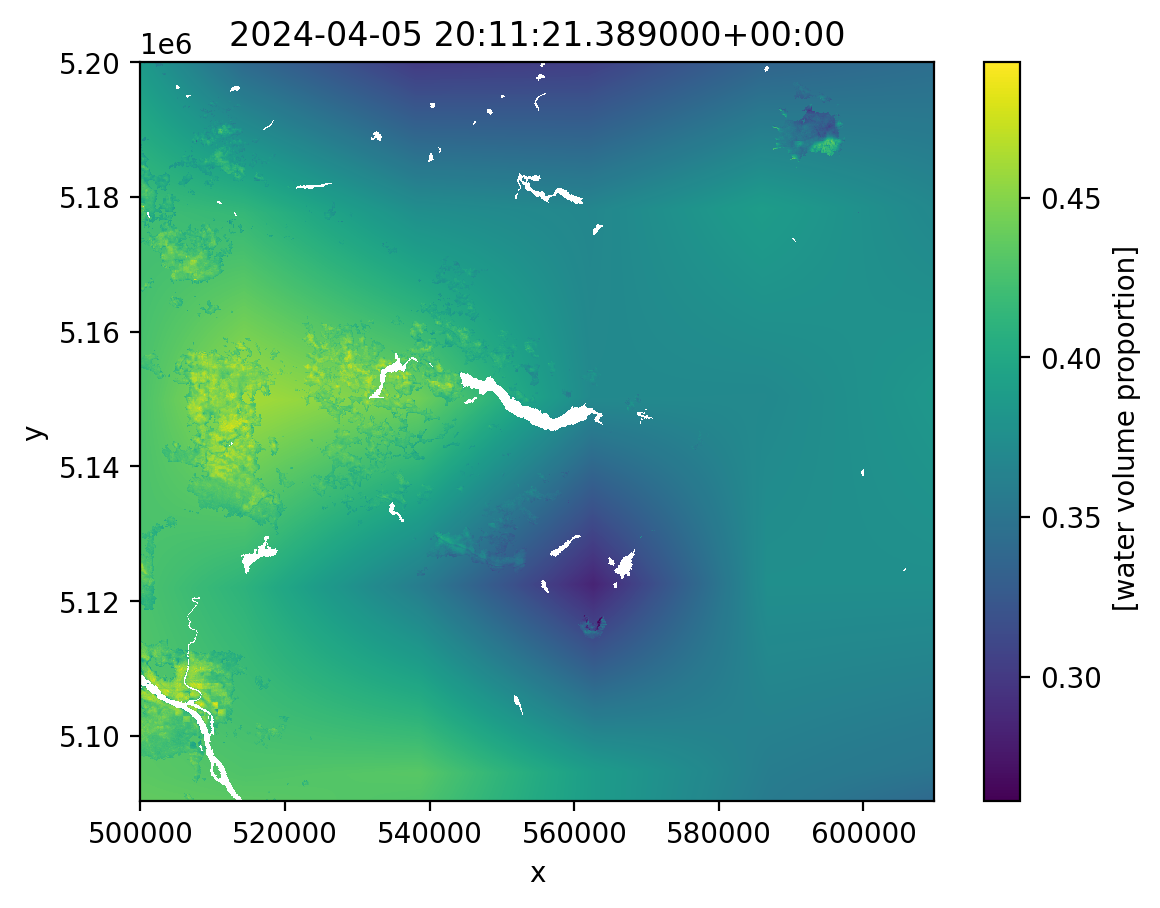

In [ ]:
da_test.plot.imshow()
plt.title(name);

In [ ]:
# ODC stac needs GDAL settings to read data (not metadata)
odc.stac.configure_rio(cloud_defaults=True,
                       verbose=False,
                       GDAL_HTTP_AUTH="BEARER",
                       CPL_VSIL_CURL_USE_S3_REDIRECT="NO",
                       GDAL_HTTP_BEARER=os.environ.get("EARTHDATA_TOKEN", "")
                       )

In [ ]:
# Load with ODC.STAC
ds = odc.stac.load(items,
                   bands=["soil_moisture", "water_mask", "cloud_mask"], # just soil moisture!
                   like=da_test, # match grid of first item
                   chunks={}, # single 'dask chunk' per COG
)

In [ ]:
ds

<xarray.Dataset> Size: 6GB
Dimensions:        (y: 1568, x: 1568, time: 188)
Coordinates:
  * y              (y) float64 13kB 5.2e+06 5.2e+06 ... 5.09e+06 5.09e+06
  * x              (x) float64 13kB 5e+05 5.001e+05 ... 6.096e+05 6.097e+05
  * time           (time) datetime64[ns] 2kB 2024-04-05T20:11:21.389000 ... 2...
    spatial_ref    int32 4B 32610
Data variables:
    soil_moisture  (time, y, x) float32 2GB dask.array<chunksize=(1, 1568, 1568), meta=np.ndarray>
    water_mask     (time, y, x) float32 2GB dask.array<chunksize=(1, 1568, 1568), meta=np.ndarray>
    cloud_mask     (time, y, x) float32 2GB dask.array<chunksize=(1, 1568, 1568), meta=np.ndarray>

In [ ]:
%%time
# plot first 10 times in a face grid to get an idea of the data quality
# TODO: should be able to speed this up... we're reading 30x files each 1568x1568 pixels
# 256x256 # Wall time: 54.5s 1min 3s NOTE: no caching,,, just takes a long time
# 1568x1568 # Wall time: 5.2s!
subset = ds.isel(time=slice(0,10)).compute() # pull in all the data to RAM w/ dask before making plots

CPU times: user 741 ms, sys: 357 ms, total: 1.1 s
Wall time: 5.66 s


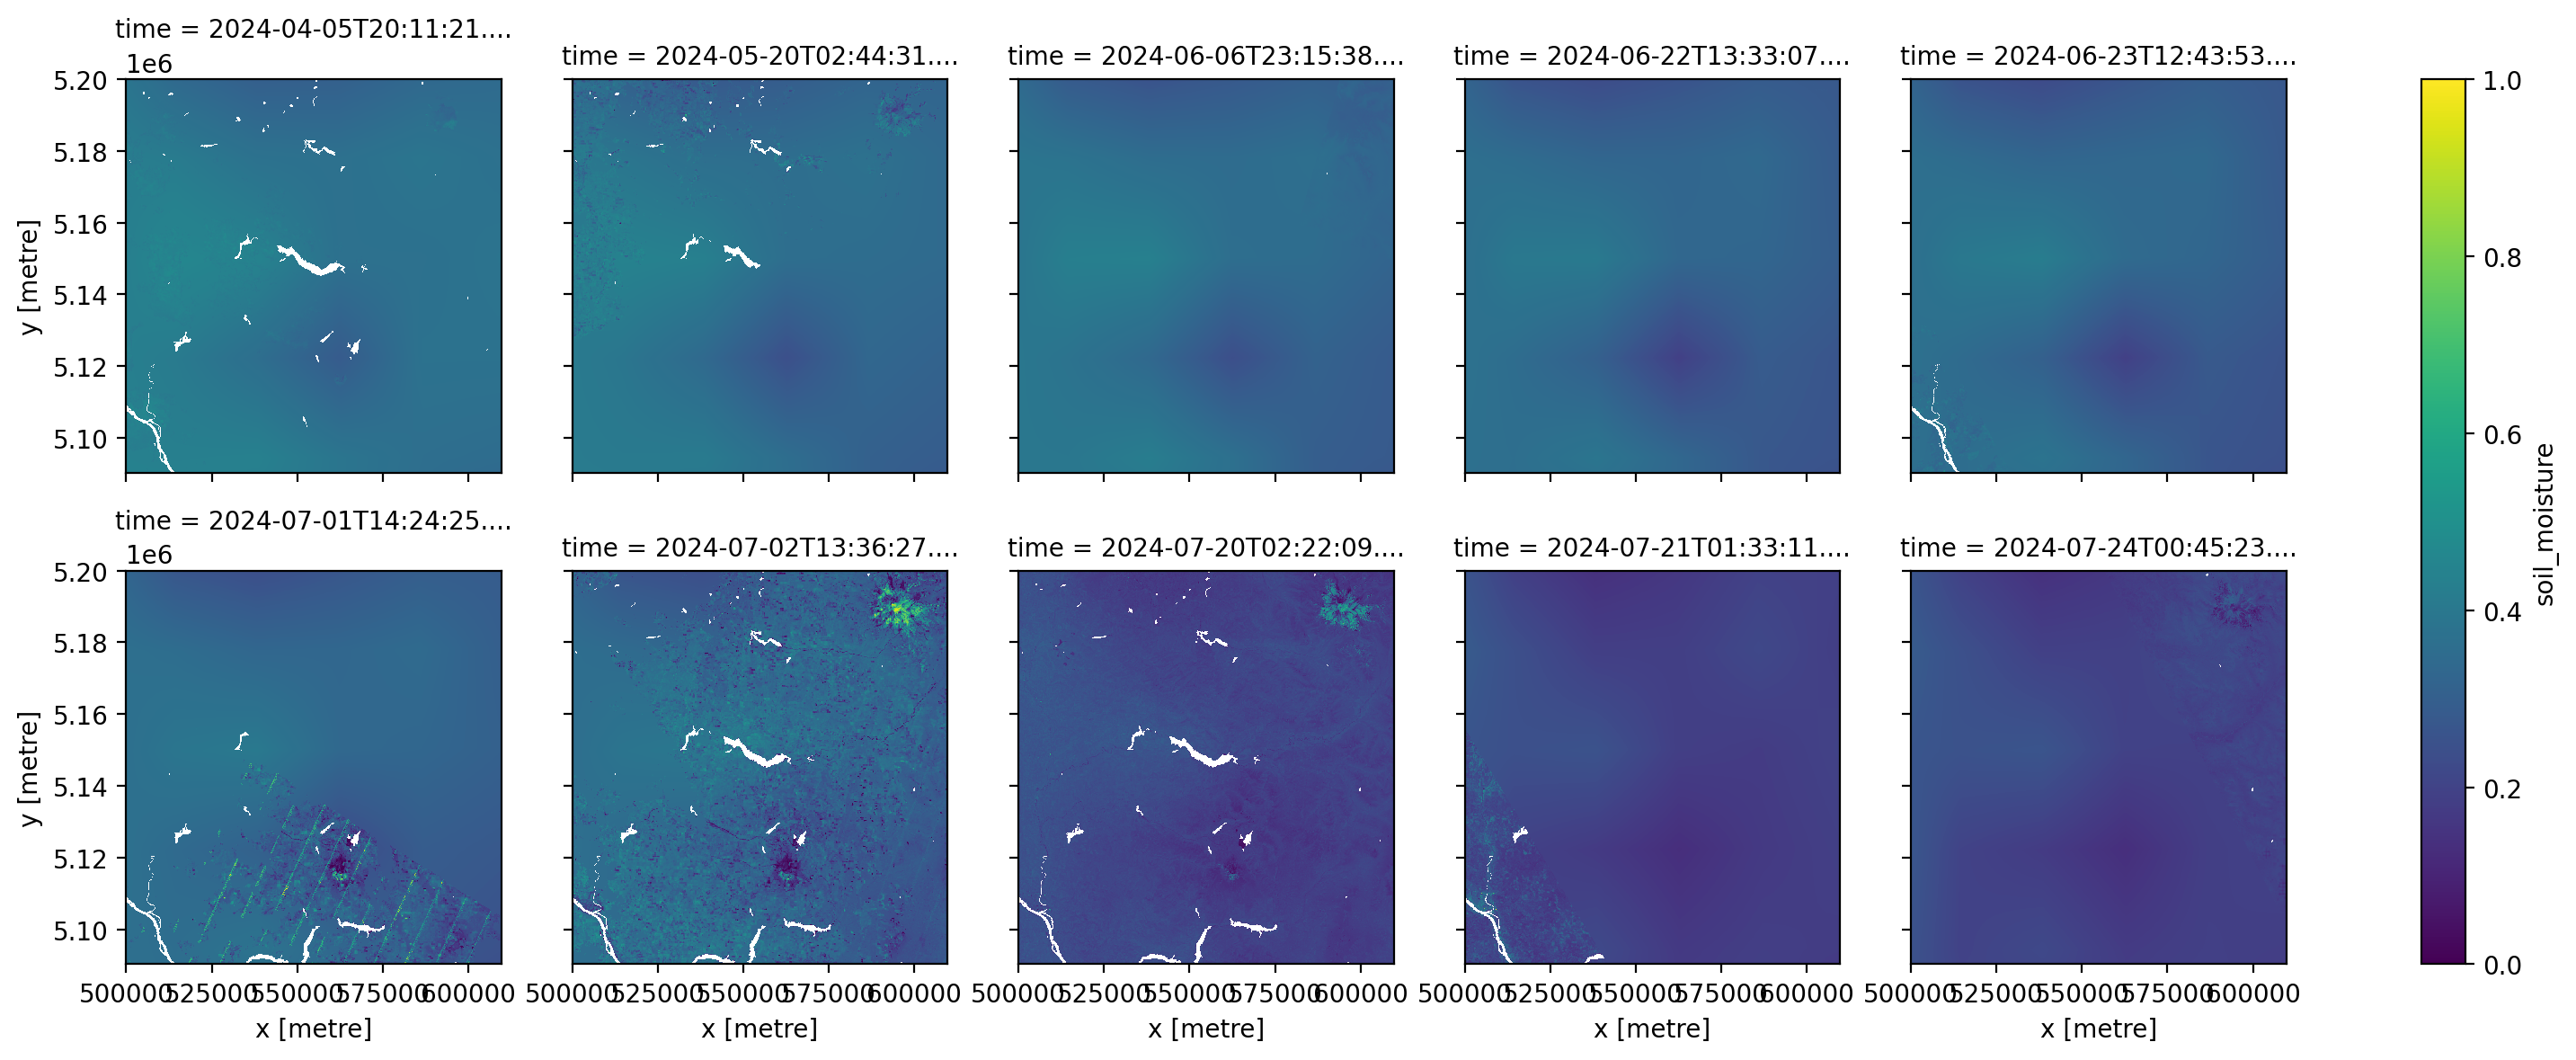

In [ ]:
subset['soil_moisture'].plot(col="time", col_wrap=5);

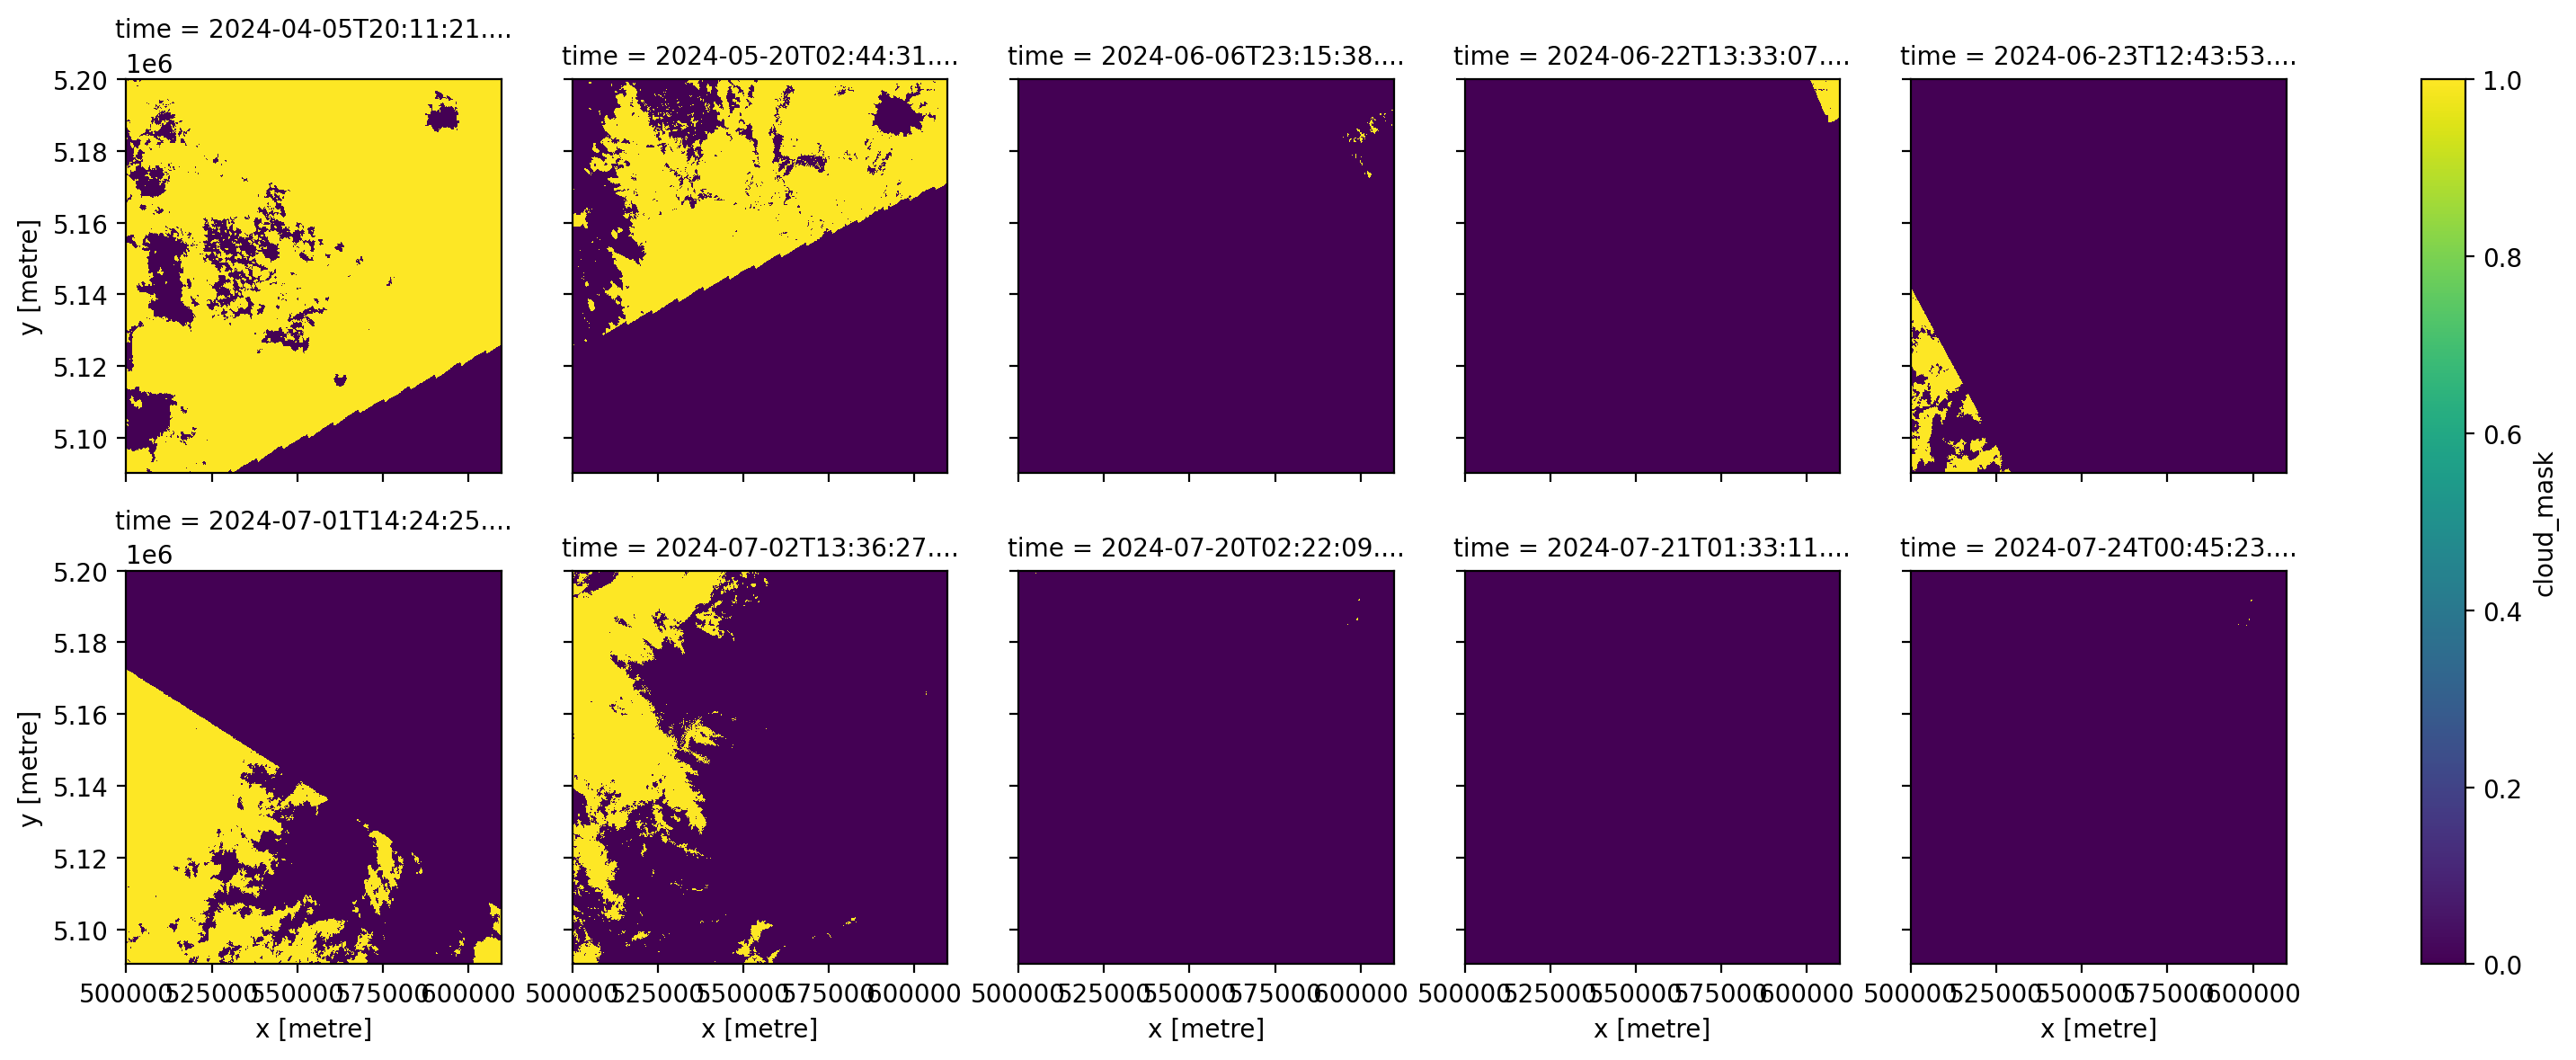

In [ ]:
# plot first 10 times in a face grid
subset.cloud_mask.plot(col="time", col_wrap=5);

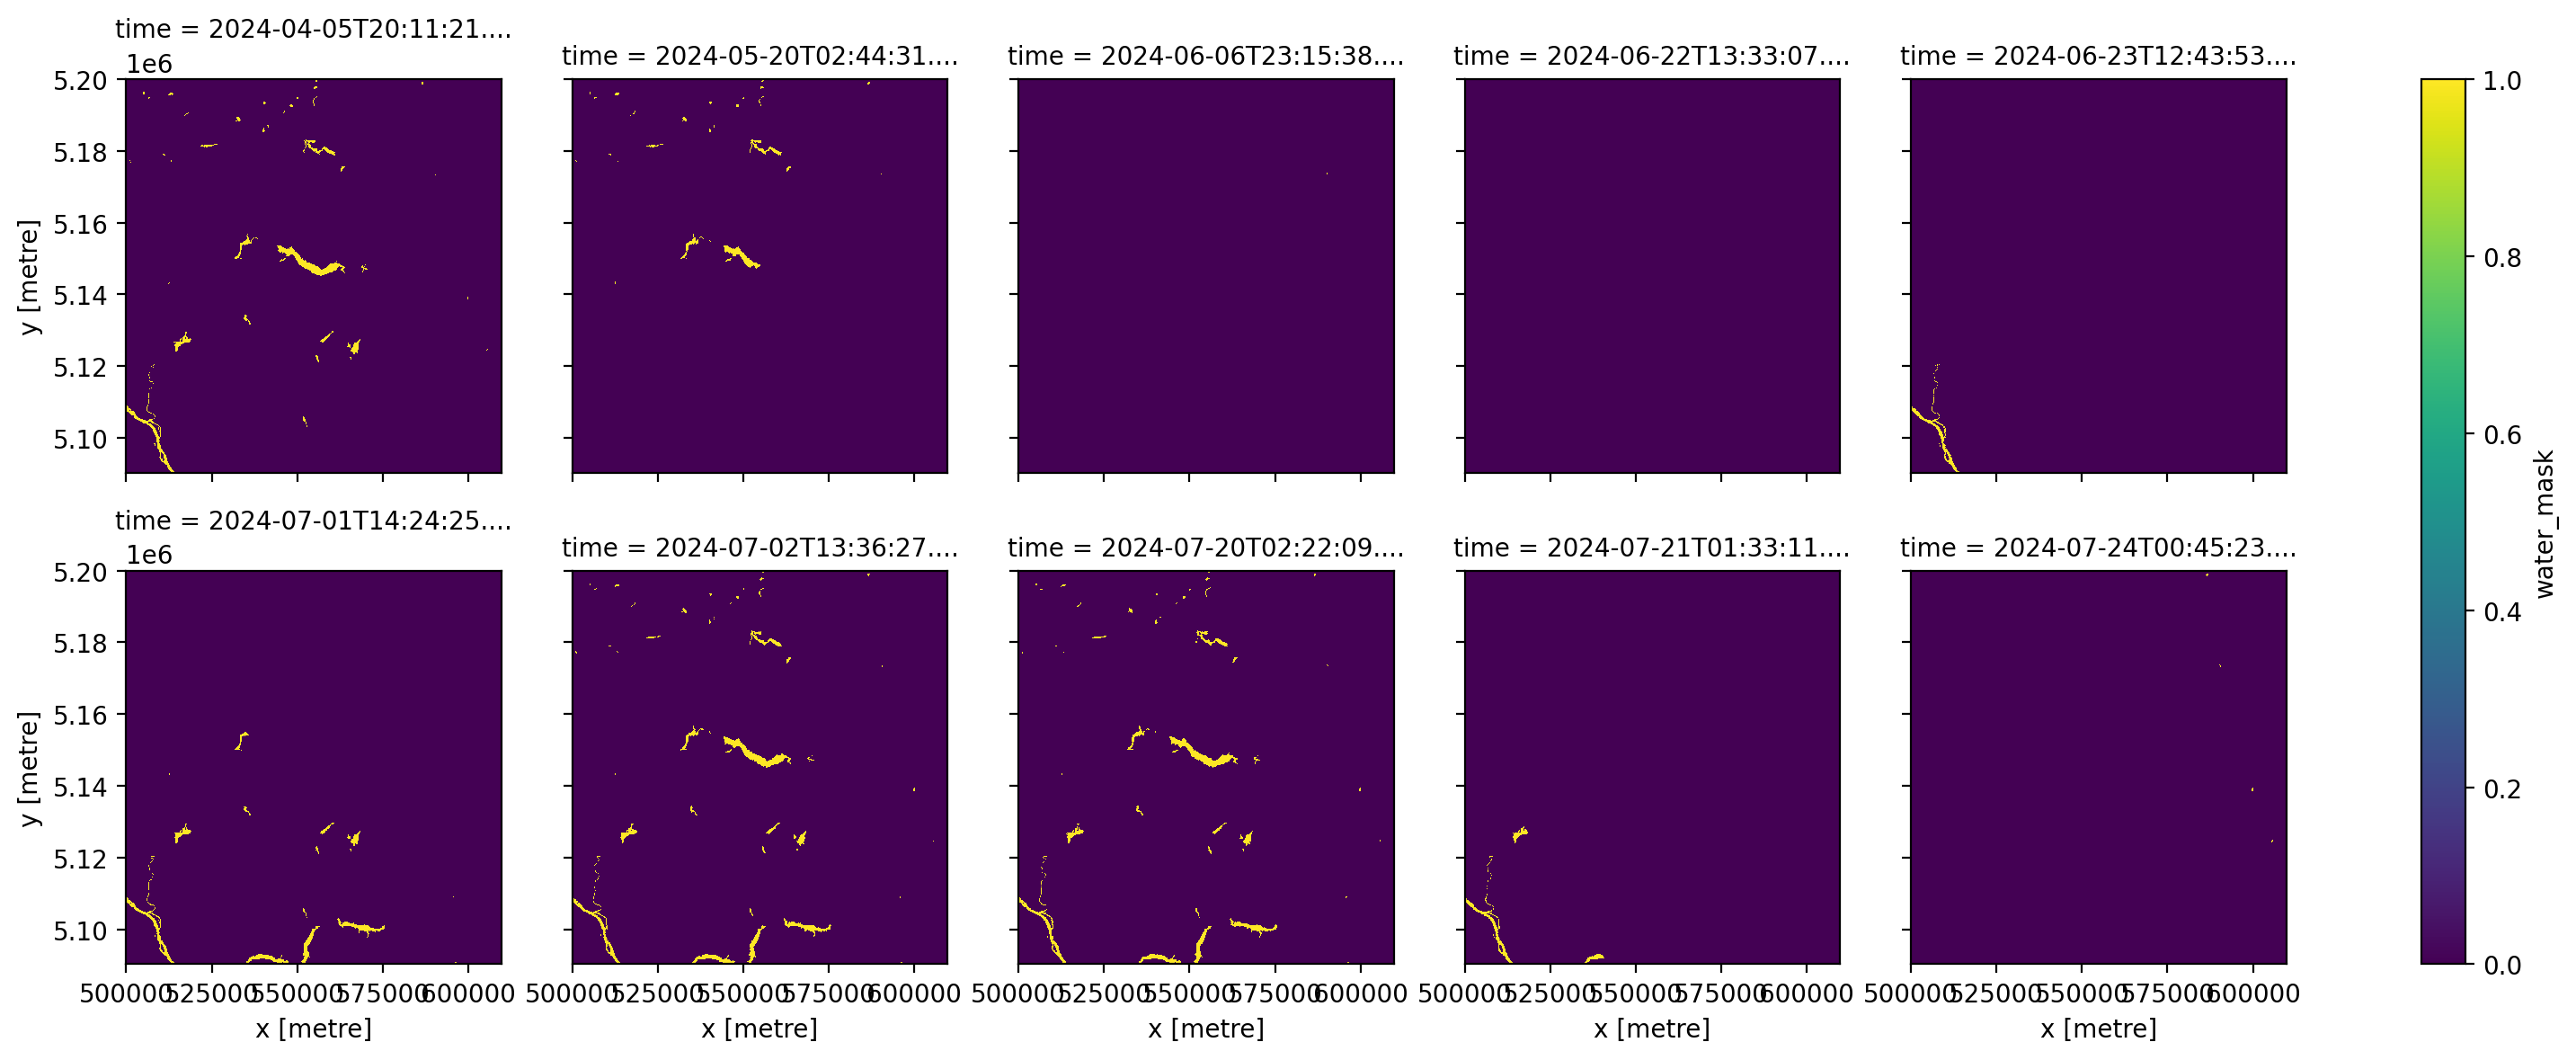

In [ ]:
# plot first 10 times in a face grid
subset.water_mask.plot(col="time", col_wrap=5);

## NOTES:

- Lots of artifacts and what seems like inconsistent data resolution and quality. Need to read user guide before interpretation
- But let's also just plot a timeseries at a weather station to see if it looks reasonable.

## Timeseries at weather station

For point extraction, we want to match the datacube chunks with COG chunks:

In [ ]:
# Load with ODC.STAC
ds = odc.stac.load(items,
                   bands=["soil_moisture", "water_mask", "cloud_mask"], # just soil moisture!
                   like=da_test, # match grid of first item
                   # Align with COG on-disk chunking to no overread data
                   chunks=dict(x=256, y=256)
)

In [ ]:
# Timeseries plot at a in-situ site  (from https://gaia-hazlab.github.io/catalog/ )
# https://explore.synopticdata.com/KCHW1/metadata
station_name = "KCHW1"
lon = -121.85639
lat = 46.72944
# NOTE: dataset is in UTM, so need to transform lat/lon to x/y
lon_lat_to_ds = pyproj.Transformer.from_crs("EPSG:4326", ds.rio.crs, always_xy=True)
x, y = lon_lat_to_ds.transform(lon,lat)
x,y

(587381.186621869, 5175733.477716236)

In [ ]:
# go to a dataframe b/c 1D!
# reading of 188 cogs, so takes a little bit...
time_series = ds.soil_moisture.sel(x=x, y=y, method="nearest").to_pandas()

In [ ]:
time_series

time
2024-04-05 20:11:21.389    0.386492
2024-05-20 02:44:31.123    0.367115
2024-06-06 23:15:38.388    0.357677
2024-06-22 13:33:07.185    0.334102
2024-06-23 12:43:53.886    0.334265
                             ...   
2026-02-09 17:01:58.711    0.391557
2026-02-10 16:14:30.391    0.379225
2026-02-10 16:15:22.361    0.389957
2026-02-18 18:03:26.600    0.378052
2026-02-23 15:46:24.966    0.376792
Name: soil_moisture, Length: 188, dtype: float32

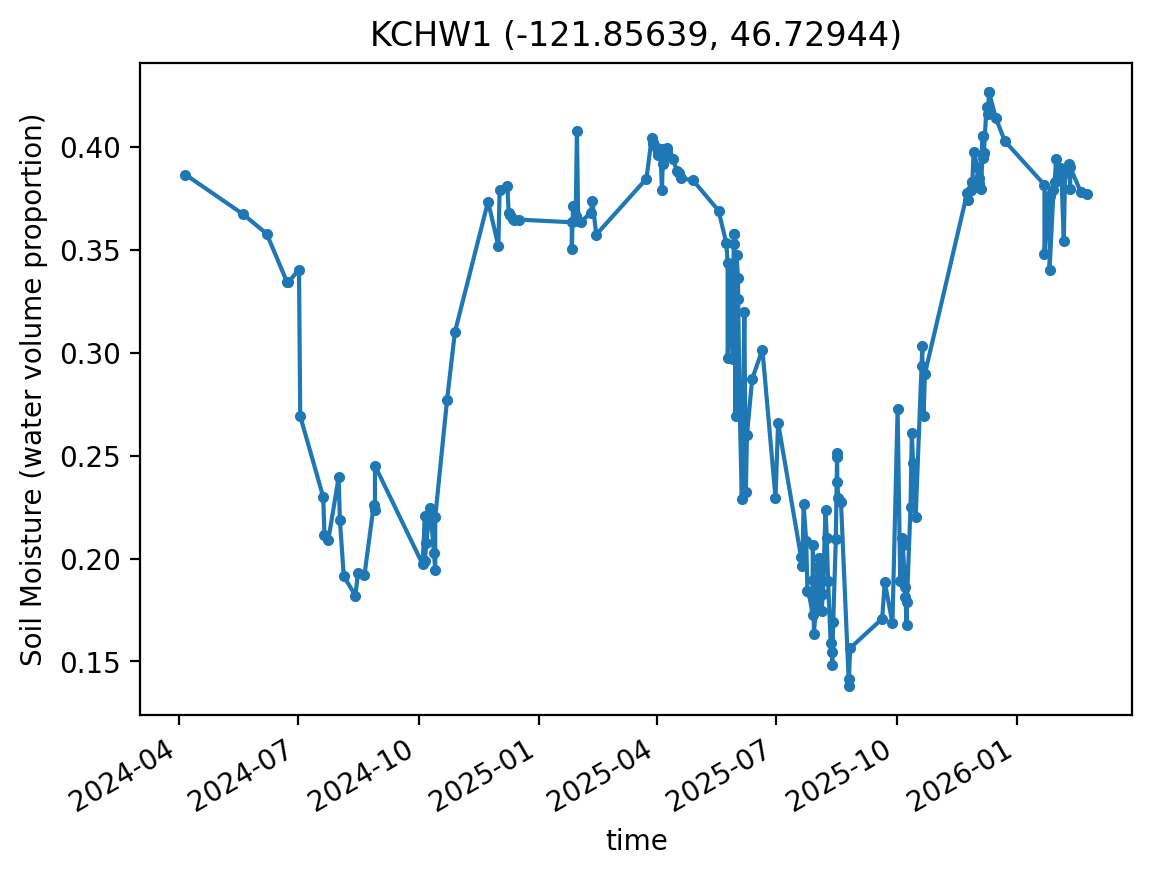

In [ ]:
# NOTE: nearest, so no interpolation / averaging:
# Getting period read errors for some reason :(
# RasterioIOError -> not recognized as being in a supported file format.
time_series.plot(marker='.')
plt.ylabel("Soil Moisture (water volume proportion)")
plt.title(f"{station_name} ({lon}, {lat})");